# 1. Library import

In [32]:
# data management
import numpy as np
import pandas as pd
import ast
from collections import Counter
# data visualisation
import seaborn as sns
import matplotlib.pyplot as plt
# Language model
from nltk.corpus import stopwords
from nltk.corpus import wordnet as wn
import nltk
# Statistical tests
import statsmodels.stats.weightstats as stests
from scipy.stats import chi2_contingency
import scipy.stats as stats
import statsmodels.formula.api as smf


In [2]:
sns.set_theme(style="darkgrid", palette="viridis", font="serif", font_scale=1.6)

# 2. Data import

## 2.1 Scripts

In [ ]:
df = pd.read_csv("data_texte.csv")

In [ ]:
df.head(5)

,Unnamed: 0,Script_Index,Phrase,Tokens,Nbr_tokens,Type_voix,Genre,Script_Original
0,0,0,Wou !,['wou'],1,Acteur,Homme,"L'homme (1) : "" Wou !\r\n (1) ... On va où Mon..."
1,1,0,Dans le 15ème !,"['dans', 'le', '15èm']",3,Acteur,Homme,"L'homme (1) : "" Wou !\r\n (1) ... On va où Mon..."
2,2,0,Mais bon port c'est une expression !,"['mais', 'bon', 'port', 'ce', 'être', 'un', 'e...",7,Acteur,Femme,"L'homme (1) : "" Wou !\r\n (1) ... On va où Mon..."
3,3,0,No !,['no'],1,Acteur,Homme,"L'homme (1) : "" Wou !\r\n (1) ... On va où Mon..."
4,4,0,"Non, non je rigole pas parce qu'après c'est lo...","['non', 'non', 'je', 'rigole', 'pas', 'parce',...",11,Acteur,Homme,"L'homme (1) : "" Wou !\r\n (1) ... On va où Mon..."


## 2.2 Voitures

In [ ]:
df_voitures = pd.read_csv("data_voitures.csv")

In [ ]:
df_voitures.head(5)

,Produit,Modèle,Longueur (mm),Largeur (mm),Hauteur (mm)
0,CAPTURCALL FR,Renault Captur,4228,1797,1566
1,NISSAN LEAF ELECTRIQUE,Nissan Leaf,4490,1789,1540
2,CITROEN LES OFFRES QUI TOMBENT A PIC C3,Citroën C3,3996,1748,1474
3,CITROEN LES OFFRES QUI TOMBENT A PIC C4,Citroën C4,4360,1800,1489
4,CITROEN LES OFFRES QUI TOMBENT A PIC C1,Citroën C1,3466,1615,1460


## 2.3 Publicités

In [ ]:
df_pub = pd.read_csv("data_pub.csv")

In [ ]:
df_pub.head(5)

,Unnamed: 0,Fiche,year,Marque,Produit,Date,Support,Format,Secteur,Classe,...,Visuel,MotsClés,Thème,Agence,Month,Electric,Hybrid,length,n,Annonceur2
0,1,4704876,2014,RENAULT CAPTUR,CAPTURCALL FR,2014-01-01,CNEWS,00:20,AUTOMOBILE TRANSPORT,AUTOMOBILES POIDS LOURDS,...,"En caméra cachée, un homme invite des personne...",CAMERA CACHEE,"INTERROGATION, HUMOUR AUTRE, NOCTURNE, TWITTER",NaN,1,0,0,141,1426,RENAULT
1,2,4705098,2014,NISSAN LEAF,NISSAN LEAF ELECTRIQUE,2014-01-01,CNEWS,00:40,AUTOMOBILE TRANSPORT,AUTOMOBILES POIDS LOURDS,...,Un homme recharge sa NISSAN LEAF et traverse u...,BALLON,"INNOVATION, UNIVERS URBAIN, ANGLAIS, EFFET, SI...",TBWA,1,1,0,165,343,NISSAN AUTOMOBILES
2,3,4706333,2014,CITROEN C3,CITROEN LES OFFRES QUI TOMBENT A PIC C3,2014-01-02,BFM TV,00:30,AUTOMOBILE TRANSPORT,AUTOMOBILES POIDS LOURDS,...,Des journalistes interrogent un homme qui vien...,"CHANCE , POMPIER , CAMERA , INTERVIEW , METEOR...","ORIGINE, GARANTIE, ESPACE, JOURNALISTIQUE, DIS...",LES GAULOIS,1,0,0,342,815,CITROEN
3,4,4706335,2014,CITROEN C4,CITROEN LES OFFRES QUI TOMBENT A PIC C4,2014-01-02,BFM TV,00:30,AUTOMOBILE TRANSPORT,AUTOMOBILES POIDS LOURDS,...,Des journalistes interrogent un homme qui vien...,"CHANCE , POMPIER , CAMERA , INTERVIEW , METEOR...","ORIGINE, GARANTIE, ESPACE, JOURNALISTIQUE, DIS...",LES GAULOIS,1,0,0,342,815,CITROEN
4,5,4706394,2014,CITROEN C1,CITROEN LES OFFRES QUI TOMBENT A PIC C1,2014-01-02,FRANCE 2,00:30,AUTOMOBILE TRANSPORT,AUTOMOBILES POIDS LOURDS,...,Des journalistes interrogent un homme qui vien...,"CHANCE , POMPIER , CAMERA , INTERVIEW , METEOR...","ESPACE, JOURNALISTIQUE, DISCOURS DECALE AUTRE,...",LES GAULOIS,1,0,0,341,815,CITROEN


## 2.4 Concat

In [ ]:
# 1. Group by Script, Genre AND Type_voix
df_script = df.groupby(['Script_Index', 'Genre', 'Type_voix'])['Nbr_tokens'].sum().unstack(['Genre', 'Type_voix'], fill_value=0)

# 2. Flatten the columns
# Currently, columns are a MultiIndex like ('Femme', 'Acteur'), ('Homme', 'Voix-off')
# We join them with an underscore to get 'Femme_Acteur', 'Homme_Voix-off', etc.
df_script.columns = [f"{genre}_{voix}" for genre, voix in df_script.columns]

# 3. Ensure all specific categories are present (Optional but safer)
# List the exact columns you expect
expected_cols = [
    'Femme_Acteur', 'Femme_Voix-off',
    'Homme_Acteur', 'Homme_Voix-off',
    'Indéterminé_Acteur', 'Indéterminé_Voix-off'
]

# Create missing columns with 0 using reindex (cleaner than the for-loop)
df_script = df_script.reindex(columns=expected_cols, fill_value=0)

# 4. Calculate your difference (example: Total Homme vs Total Femme)
# You can now sum your new specific columns to reconstruct the totals if needed
df_script['Total_Homme'] = df_script['Homme_Acteur'] + df_script['Homme_Voix-off']
df_script['Total_Femme'] = df_script['Femme_Acteur'] + df_script['Femme_Voix-off']
df_script['Diff_tokens_gender'] = df_script['Total_Homme'] - df_script['Total_Femme']

df_script.head(5)

,Femme_Acteur,Femme_Voix-off,Homme_Acteur,Homme_Voix-off,Indéterminé_Acteur,Indéterminé_Voix-off,Total_Homme,Total_Femme,Diff_tokens_gender
Script_Index,,,,,,,,,
0,22,0,16,0,0,0,16,22,-6
1,0,0,0,6,0,0,6,0,6
2,4,0,1,0,0,0,1,4,-3
3,4,0,1,0,0,0,1,4,-3
4,4,0,1,0,0,0,1,4,-3


In [ ]:
# Step 0: Ensure Script_Index is a column in df_script
# (If it's currently the index, this moves it to a column)
if 'Script_Index' not in df_script.columns:
    df_script = df_script.reset_index()

# Step 1: Join df_script with df_pub
# We use 'Script_Index' from df_script and the Index from df_pub
df_step1 = df_script.merge(df_pub,
                           left_on='Script_Index',
                           right_index=True,
                           how='left') # Use 'left' to keep all scripts even if no pub info

# Step 2: Join the result with df_voitures
# We connect using the 'Produit' column found in both
df_final = df_step1.merge(df_voitures,
                          on='Produit',
                          how='left')

# Check the result
print(df_final.columns)
df_final.head()

Index(['Script_Index', 'Femme_Acteur', 'Femme_Voix-off', 'Homme_Acteur',
       'Homme_Voix-off', 'Indéterminé_Acteur', 'Indéterminé_Voix-off',
       'Total_Homme', 'Total_Femme', 'Diff_tokens_gender', 'Unnamed: 0',
       'Fiche', 'year', 'Marque', 'Produit', 'Date', 'Support', 'Format',
       'Secteur', 'Classe', 'Groupe', 'Variété', 'N° Groupe/Variété',
       'Signature', 'Script', 'Incrustation', 'Titre', 'Version', 'Visuel',
       'MotsClés', 'Thème', 'Agence', 'Month', 'Electric', 'Hybrid', 'length',
       'n', 'Annonceur2', 'Modèle', 'Longueur (mm)', 'Largeur (mm)',
       'Hauteur (mm)'],
      dtype='object')


,Script_Index,Femme_Acteur,Femme_Voix-off,Homme_Acteur,Homme_Voix-off,Indéterminé_Acteur,Indéterminé_Voix-off,Total_Homme,Total_Femme,Diff_tokens_gender,...,Month,Electric,Hybrid,length,n,Annonceur2,Modèle,Longueur (mm),Largeur (mm),Hauteur (mm)
0,0,22,0,16,0,0,0,16,22,-6,...,1,0,0,141,1426,RENAULT,Renault Captur,4228,1797,1566
1,1,0,0,0,6,0,0,6,0,6,...,1,1,0,165,343,NISSAN AUTOMOBILES,Nissan Leaf,4490,1789,1540
2,2,4,0,1,0,0,0,1,4,-3,...,1,0,0,342,815,CITROEN,Citroën C3,3996,1748,1474
3,3,4,0,1,0,0,0,1,4,-3,...,1,0,0,342,815,CITROEN,Citroën C4,4360,1800,1489
4,4,4,0,1,0,0,0,1,4,-3,...,1,0,0,341,815,CITROEN,Citroën C1,3466,1615,1460


In [ ]:
# List of columns to keep
columns_to_keep = [
    'Script_Index', 'Produit', 'Script', 'Titre',
    'Femme_Acteur', 'Femme_Voix-off', 'Homme_Acteur',
    'Homme_Voix-off', 'Indéterminé_Acteur', 'Indéterminé_Voix-off',
    'Total_Homme', 'Total_Femme', 'Diff_tokens_gender',
    'MotsClés', 'Thème', 'Electric', 'Hybrid',
    'Modèle', 'Longueur (mm)', 'Largeur (mm)', 'Hauteur (mm)'
]

# Create a new dataframe with only the selected columns
df_concat = df_final[columns_to_keep]

In [ ]:
df_concat.head()

,Script_Index,Produit,Script,Titre,Femme_Acteur,Femme_Voix-off,Homme_Acteur,Homme_Voix-off,Indéterminé_Acteur,Indéterminé_Voix-off,...,Total_Femme,Diff_tokens_gender,MotsClés,Thème,Electric,Hybrid,Modèle,Longueur (mm),Largeur (mm),Hauteur (mm)
0,0,CAPTURCALL FR,"L'homme (1) : "" Wou !\r\n (1) ... On va où Mon...",EN VOITURE,22,0,16,0,0,0,...,22,-6,CAMERA CACHEE,"INTERROGATION, HUMOUR AUTRE, NOCTURNE, TWITTER",0,0,Renault Captur,4228,1797,1566
1,1,NISSAN LEAF ELECTRIQUE,"Voix homme : "" 85 000 conducteurs vivent la se...",LA SENSATION 100% ELECTRIQUE,0,0,0,6,0,0,...,0,6,BALLON,"INNOVATION, UNIVERS URBAIN, ANGLAIS, EFFET, SI...",1,0,Nissan Leaf,4490,1789,1540
2,2,CITROEN LES OFFRES QUI TOMBENT A PIC C3,"La femme (1) : "" C'est votre voiture ?\r\n L'h...",LA MÉTÉORITE,4,0,1,0,0,0,...,4,-3,"CHANCE , POMPIER , CAMERA , INTERVIEW , METEOR...","ORIGINE, GARANTIE, ESPACE, JOURNALISTIQUE, DIS...",0,0,Citroën C3,3996,1748,1474
3,3,CITROEN LES OFFRES QUI TOMBENT A PIC C4,"La femme (1) : "" C'est votre voiture ?\r\n L'h...",LE MÉTÉORITE,4,0,1,0,0,0,...,4,-3,"CHANCE , POMPIER , CAMERA , INTERVIEW , METEOR...","ORIGINE, GARANTIE, ESPACE, JOURNALISTIQUE, DIS...",0,0,Citroën C4,4360,1800,1489
4,4,CITROEN LES OFFRES QUI TOMBENT A PIC C1,"La femme (1) : "" C'est votre voiture ?\r\n L'h...",LE MÉTÉORITE,4,0,1,0,0,0,...,4,-3,"CHANCE , POMPIER , CAMERA , INTERVIEW , METEOR...","ESPACE, JOURNALISTIQUE, DISCOURS DECALE AUTRE,...",0,0,Citroën C1,3466,1615,1460


# 3. Data manipulation

## 3.1 Total tokens per script

In [ ]:
# Calculate total tokens per script and normalize
df['Total_tokens_per_script'] = df.groupby('Script_Index')['Nbr_tokens'].transform('sum')
df['Nbr_tokens_sd'] = df['Nbr_tokens'] / df['Total_tokens_per_script']
df.head(3)

,Unnamed: 0,Script_Index,Phrase,Tokens,Nbr_tokens,Type_voix,Genre,Script_Original,Total_tokens_per_script,Nbr_tokens_sd
0,0,0,Wou !,['wou'],1,Acteur,Homme,"L'homme (1) : "" Wou !\r\n (1) ... On va où Mon...",38,0.026316
1,1,0,Dans le 15ème !,"['dans', 'le', '15èm']",3,Acteur,Homme,"L'homme (1) : "" Wou !\r\n (1) ... On va où Mon...",38,0.078947
2,2,0,Mais bon port c'est une expression !,"['mais', 'bon', 'port', 'ce', 'être', 'un', 'e...",7,Acteur,Femme,"L'homme (1) : "" Wou !\r\n (1) ... On va où Mon...",38,0.184211


In [ ]:
df["Type_voix"].unique()

array(['Acteur', 'Voix-off'], dtype=object)

## 3.2 Loose the "indéterminé" for tests

In [25]:
# Filter data to only include Femme and Homme
df_filtered = df[df['Genre'].isin(['Femme', 'Homme'])].copy()

In [ ]:
# Créer un dataset pour la comparaison Homme vs Femme
df_script_filtered = df_script[['Total_Homme', 'Total_Femme']].copy()

## 3.3 Car volume calculation

In [ ]:
for col in ['Longueur (mm)', 'Largeur (mm)', 'Hauteur (mm)']:
    df_concat[col] = pd.to_numeric(df_concat[col], errors='coerce')

df_concat["Volume"] = (df_concat['Longueur (mm)'] * df_concat['Largeur (mm)'] * df_concat['Hauteur (mm)'] / 1e9).round(2)
df_concat[['Produit', 'Volume']].head()

/tmp/ipython-input-2118382693.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_concat[col] = pd.to_numeric(df_concat[col], errors='coerce')
/tmp/ipython-input-2118382693.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_concat["Volume"] = (df_concat['Longueur (mm)'] * df_concat['Largeur (mm)'] * df_concat['Hauteur (mm)'] / 1e9).round(2)


,Produit,Volume
0,CAPTURCALL FR,11.90
1,NISSAN LEAF ELECTRIQUE,12.37
2,CITROEN LES OFFRES QUI TOMBENT A PIC C3,10.30
3,CITROEN LES OFFRES QUI TOMBENT A PIC C4,11.69
4,CITROEN LES OFFRES QUI TOMBENT A PIC C1,8.17


# 4. Data description

## 4.1 Tokens, sentences & gender

In [ ]:
genre_order = ["Femme", "Homme", "Indéterminé"]
# Define consistent colors for each genre
palette_dict = {
    "Femme": sns.color_palette("viridis", 3)[0],  # First color from viridis
    "Homme": sns.color_palette("viridis", 3)[1],   # Second color from viridis
    "Indéterminé": sns.color_palette("viridis", 3)[2]  # Third color from viridis
}

In [ ]:
genre_counts = df['Genre'].value_counts().reindex(genre_order)
print(genre_counts)

Genre
Femme          1863
Homme          3742
Indéterminé      99
Name: count, dtype: int64


In [ ]:
# Table of number of words by gender
genre_sums = df.groupby('Genre')['Nbr_tokens'].sum().reindex(genre_order).reset_index()
print(genre_sums)

         Genre  Nbr_tokens
0        Femme       12503
1        Homme       23959
2  Indéterminé         477


C:\Users\lucil\AppData\Local\Temp\ipykernel_2120\548953292.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tokens_melted, x='Genre', y='Nombre_tokens',


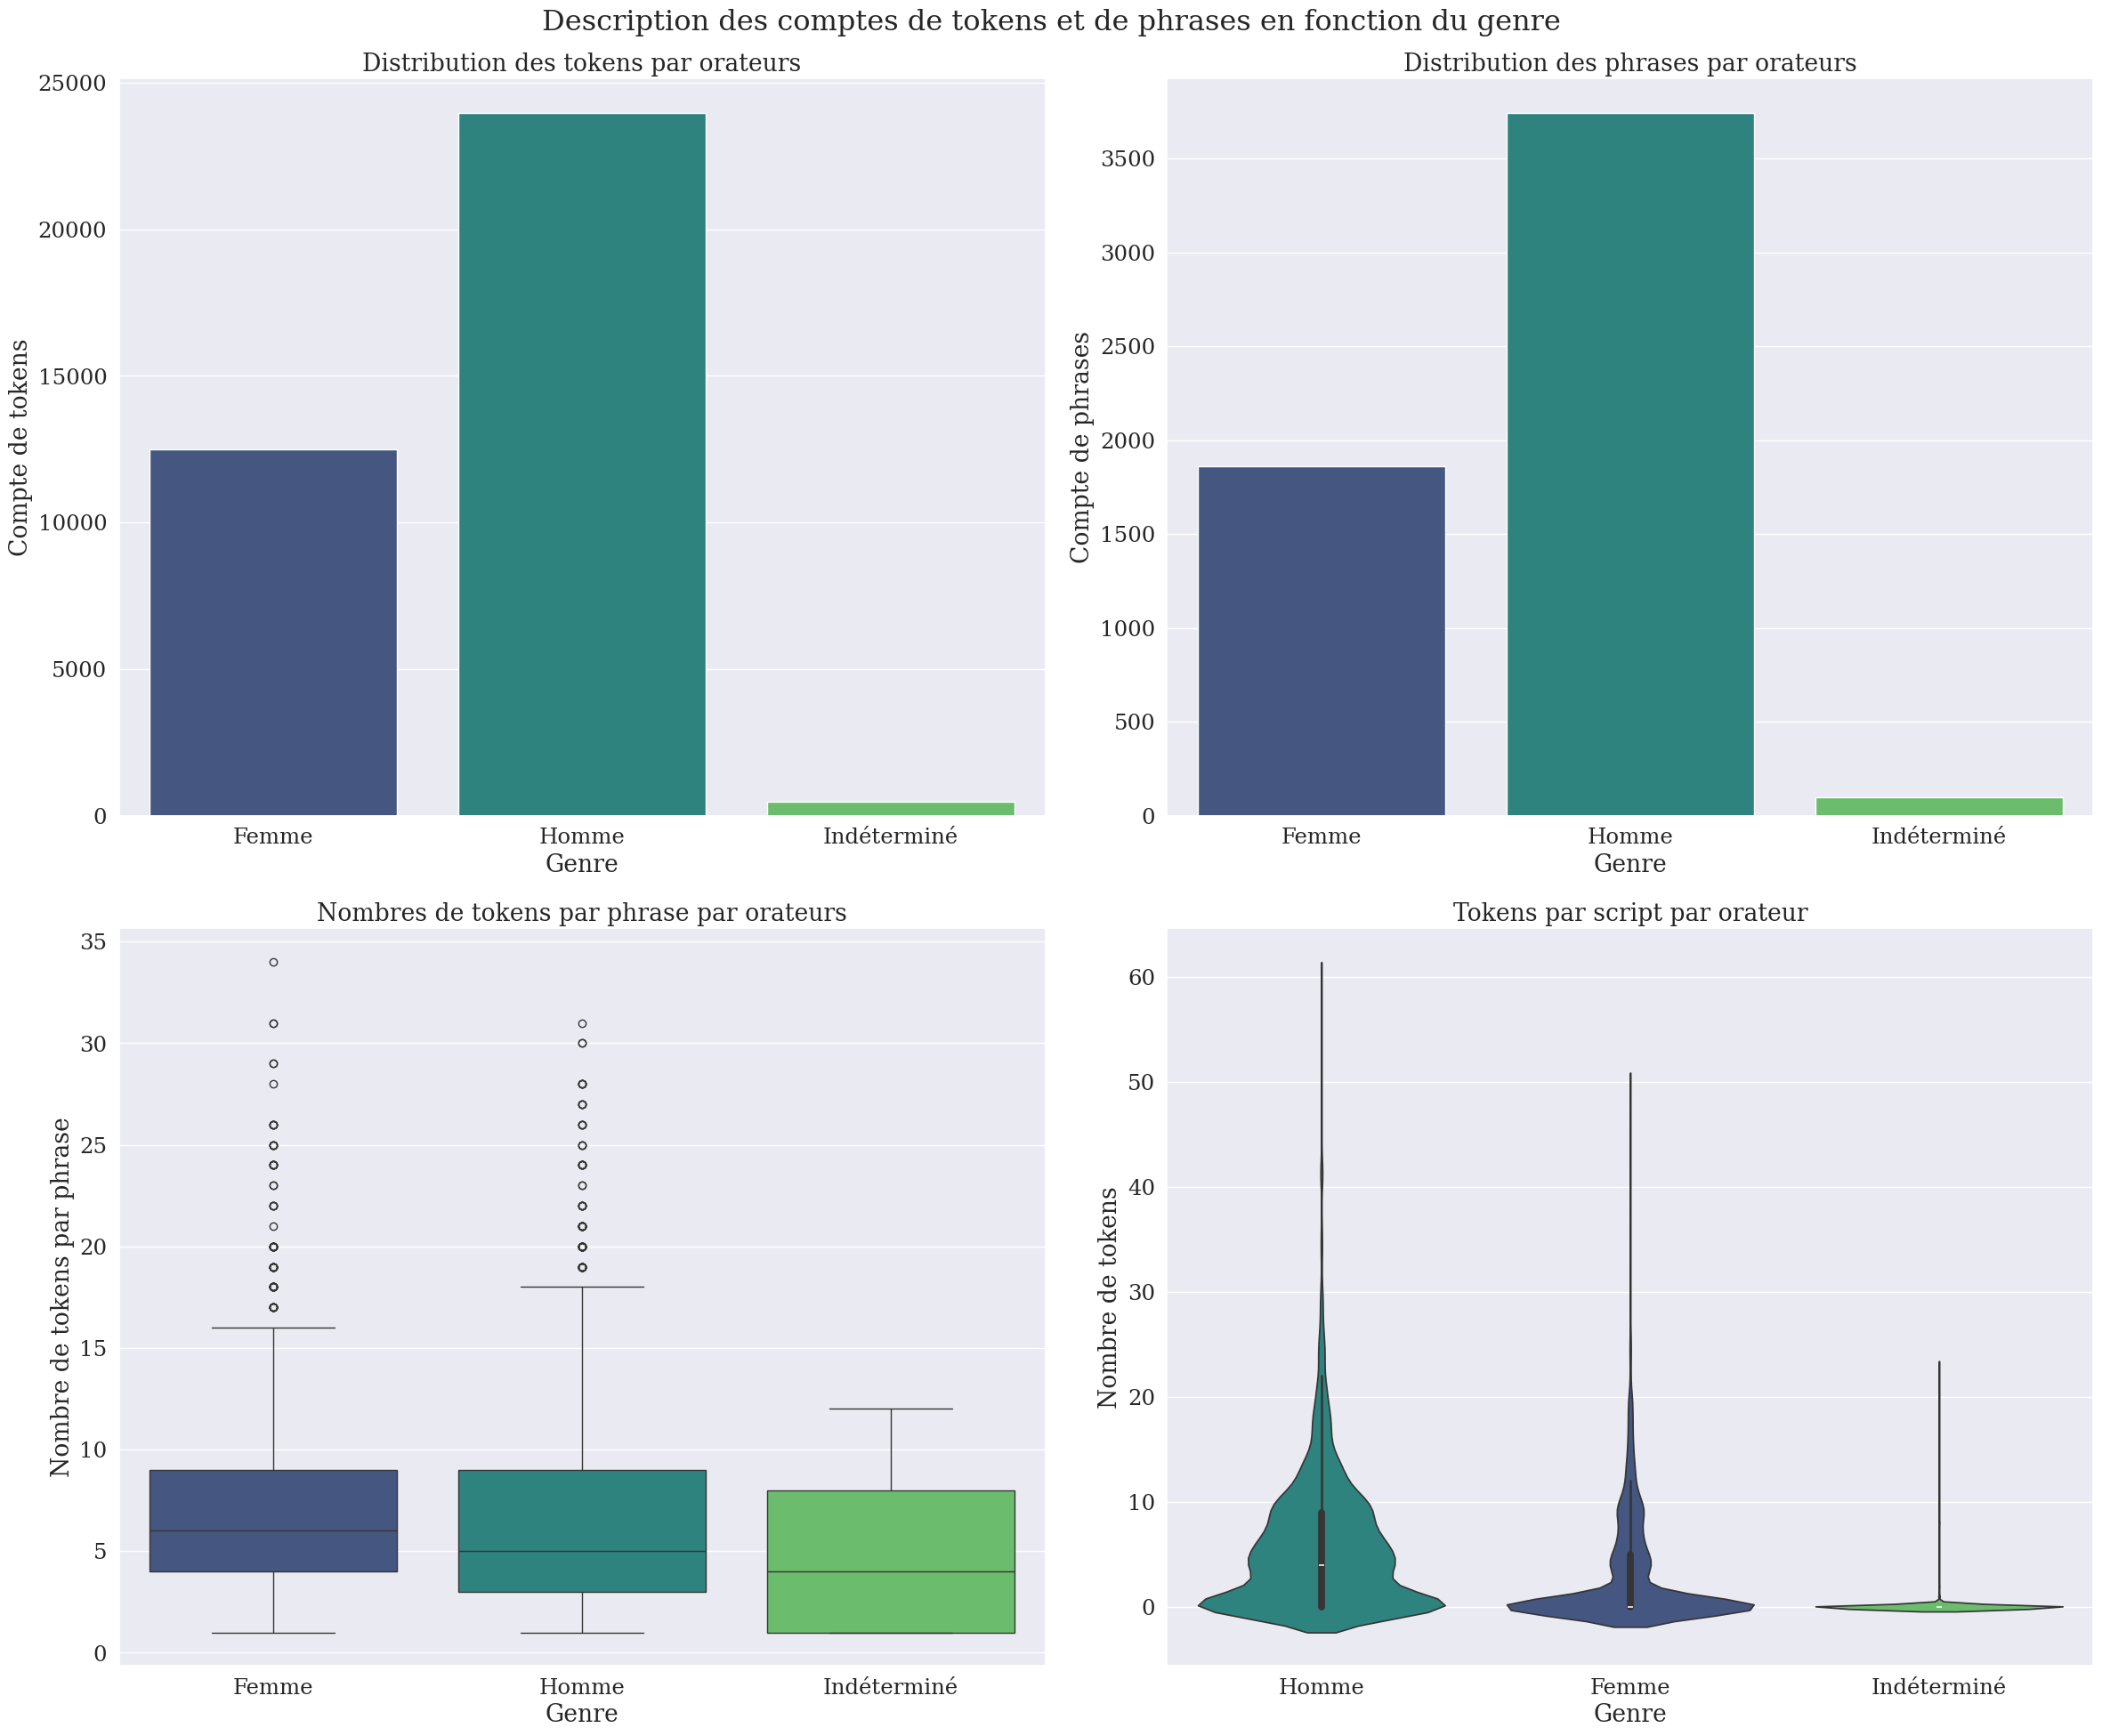

In [ ]:
# Create a figure with two subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(24, 20))
plt.suptitle("Description des comptes de tokens et de phrases en fonction du genre")

# BARPLOT: Sum of Nbr_tokens by Genre
sns.barplot(data=genre_sums, x='Genre', y='Nbr_tokens', ax=ax1,
            hue='Genre', legend=False, palette=palette_dict, order=genre_order)
ax1.set_title("Distribution des tokens par orateurs")
ax1.set_xlabel('Genre')
ax1.set_ylabel('Compte de tokens')
ax1.tick_params(axis='x')

# BARPLOT: Sum of Nbr_sentences by Gender
sns.barplot(x=genre_counts.index, y=genre_counts.values, ax=ax2,
            hue=genre_counts.index, legend=False, palette=palette_dict)
ax2.set_title("Distribution des phrases par orateurs")
ax2.set_xlabel('Genre')
ax2.set_ylabel('Compte de phrases')
ax2.tick_params(axis='x')

# BOXPLOT: Distribution of Nbr_tokens by Genre
sns.boxplot(data=df, x='Genre', y='Nbr_tokens', ax=ax3,
            hue='Genre', palette=palette_dict, legend=False, order=genre_order)
ax3.set_title('Nombres de tokens par phrase par orateurs')
ax3.set_xlabel('Genre')
ax3.set_ylabel('Nombre de tokens par phrase')
ax3.tick_params(axis='x')

# BOXPLOT: Distribution of Nbr of sentences by Gender
tokens_melted = df_script.reset_index().melt(
    id_vars='Script_Index',
    value_vars=['Homme', 'Femme', 'Indéterminé'],
    var_name='Genre',
    value_name='Nombre_tokens'
)

sns.violinplot(data=tokens_melted, x='Genre', y='Nombre_tokens',
            ax=ax4, order=['Homme', 'Femme', 'Indéterminé'],
            palette=palette_dict)
ax4.set_title('Tokens par script par orateur')
ax4.set_xlabel('Genre')
ax4.set_ylabel('Nombre de tokens')

plt.tight_layout()
plt.savefig("pub_descr.png")
plt.show()

## 4.1 Gender & Voice tokens distribution

In [ ]:
# Table 1: Count of occurrences by Type voix and Genre
count_table = pd.crosstab(df['Type_voix'], df['Genre'], margins=True, margins_name="Total")
print("=== TABLE 1: Count of occurrences by Type voix and Genre ===")
print(count_table)
print()

# Table 2: Formatted sum of Nbr_tokens by Type voix and Genre
print("=== TABLE 2 : Sum of Nbr_tokens by Type voix and Genre ===")
sum_table = pd.pivot_table(df, values='Nbr_tokens', index='Type_voix', columns='Genre',
                          aggfunc='sum', margins=True, margins_name="Total")
sum_table_formatted = sum_table.applymap(lambda x: f"{x:.0f}" if pd.notnull(x) else "0")
print(sum_table_formatted)
print()

# Table 3: Percentage of occurrences by Type voix and Genre (Grand Total = 100%)
print("=== TABLE 3: Percentage of occurrences by Type voix and Genre ===")
percent_table = pd.crosstab(df['Type_voix'], df['Genre'],
                           margins=True, margins_name="Total",
                           normalize='index') * 100
# Format as percentages with 2 decimal places
percent_table_formatted = percent_table.applymap(lambda x: f"{x:.2f}%" if pd.notnull(x) else "0.00%")
print(percent_table_formatted)
print()

# Percentage of total Nbr_tokens by Type voix and Genre
print("=== TABLE 4: Percentage of total Nbr_tokens by Type voix and Genre ===")
sum_table = pd.pivot_table(df, values='Nbr_tokens', index='Type_voix',
                          columns='Genre', aggfunc='sum',
                          margins=True, margins_name='Total')
# Calculate percentages
sum_percent_table = (sum_table / sum_table.loc['Total', 'Total'] * 100)
sum_percent_formatted = sum_percent_table.applymap(lambda x: f"{x:.2f}%" if pd.notnull(x) else "0.00%")
print(sum_percent_formatted)

=== TABLE 1: Count of occurrences by Type voix and Genre ===
Genre      Femme  Homme  Indéterminé  Total
Type_voix                                  
Acteur       935   2107           99   3141
Voix-off     928   1635            0   2563
Total       1863   3742           99   5704

=== TABLE 2 : Sum of Nbr_tokens by Type voix and Genre ===
Genre      Femme  Homme Indéterminé  Total
Type_voix                                 
Acteur      5409  12284         477  18170
Voix-off    7094  11675           0  18769
Total      12503  23959         477  36939

=== TABLE 3: Percentage of occurrences by Type voix and Genre ===
Genre       Femme   Homme Indéterminé
Type_voix                            
Acteur     29.77%  67.08%       3.15%
Voix-off   36.21%  63.79%       0.00%
Total      32.66%  65.60%       1.74%

=== TABLE 4: Percentage of total Nbr_tokens by Type voix and Genre ===
Genre       Femme   Homme Indéterminé    Total
Type_voix                                     
Acteur     14.64%  33

C:\Users\lucil\AppData\Local\Temp\ipykernel_2120\1285161166.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sum_table_formatted = sum_table.applymap(lambda x: f"{x:.0f}" if pd.notnull(x) else "0")
C:\Users\lucil\AppData\Local\Temp\ipykernel_2120\1285161166.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  percent_table_formatted = percent_table.applymap(lambda x: f"{x:.2f}%" if pd.notnull(x) else "0.00%")
C:\Users\lucil\AppData\Local\Temp\ipykernel_2120\1285161166.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sum_percent_formatted = sum_percent_table.applymap(lambda x: f"{x:.2f}%" if pd.notnull(x) else "0.00%")


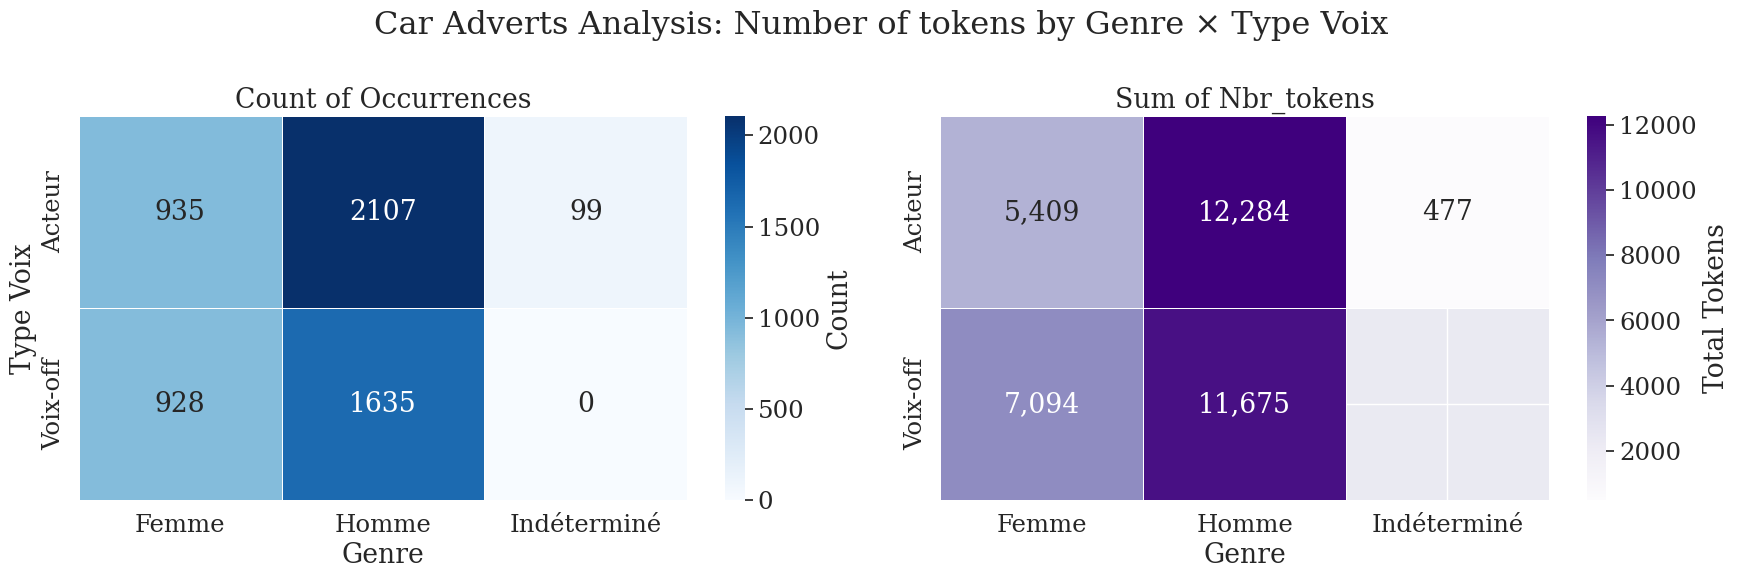

In [ ]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap 1: Counts
sns.heatmap(count_table.iloc[:-1, :-1],
           ax=axes[0],
           annot=True, fmt='d',
           cmap='Blues',
           linewidths=0.5,
           cbar_kws={'label': 'Count'})
axes[0].set_title('Count of Occurrences')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Type Voix')

# Heatmap 2: Sum of tokens
sns.heatmap(sum_table.iloc[:-1, :-1],
           ax=axes[1],
           annot=True, fmt=',.0f',
           cmap='Purples',
           linewidths=0.5,
           cbar_kws={'label': 'Total Tokens'})
axes[1].set_title('Sum of Nbr_tokens')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('')

plt.suptitle('Car Adverts Analysis: Number of tokens by Genre × Type Voix')
plt.tight_layout()
plt.show()

## 4.3 Length of speech difference

In [ ]:
sns.set_theme(style="darkgrid", palette="viridis", font="serif", font_scale=1.6)

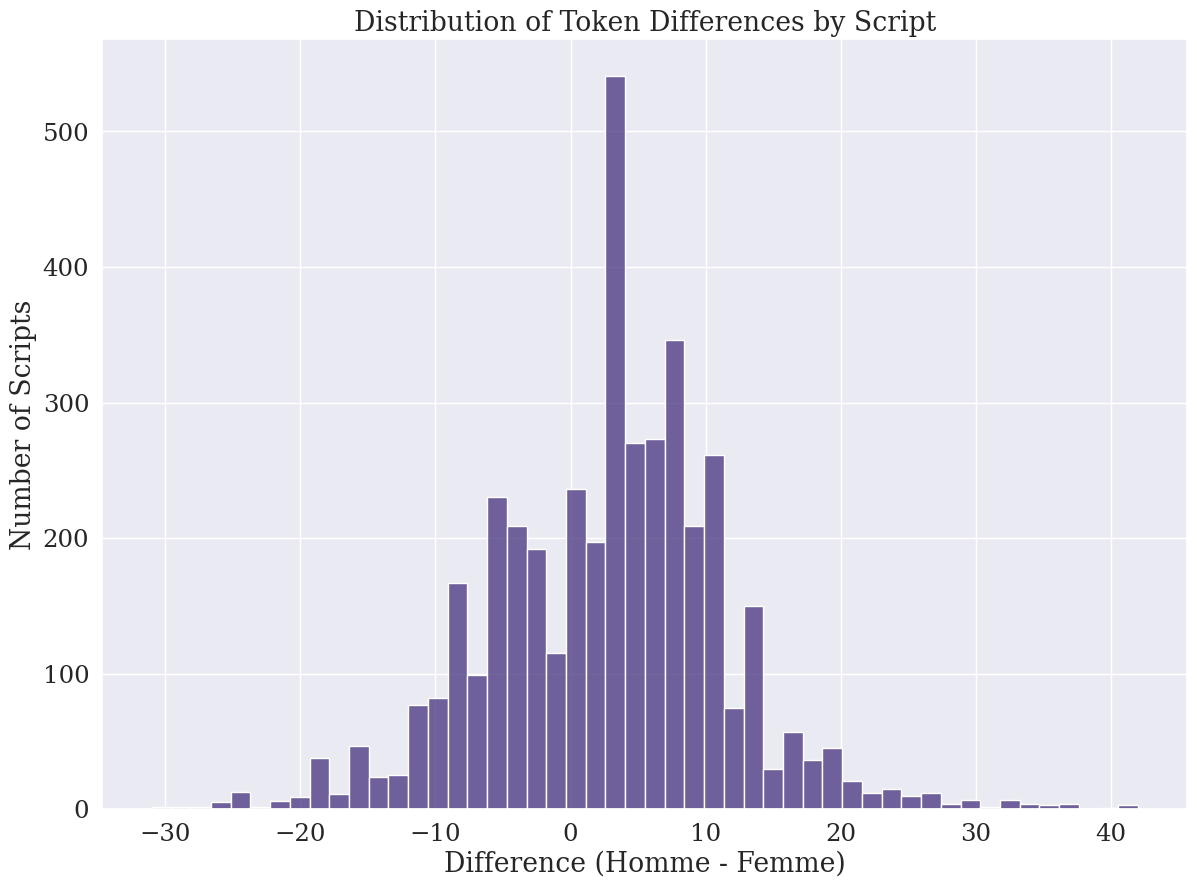

In [ ]:
plt.rcParams['figure.figsize'] = (14, 10)

sns.histplot(data=df_concat, x='Diff_tokens_gender')
plt.xlabel('Difference (Homme - Femme)')
plt.ylabel('Number of Scripts')
plt.title('Distribution of Token Differences by Script')

plt.savefig('gender_token_differences.png')
plt.show()

## 4.4 Car sizes

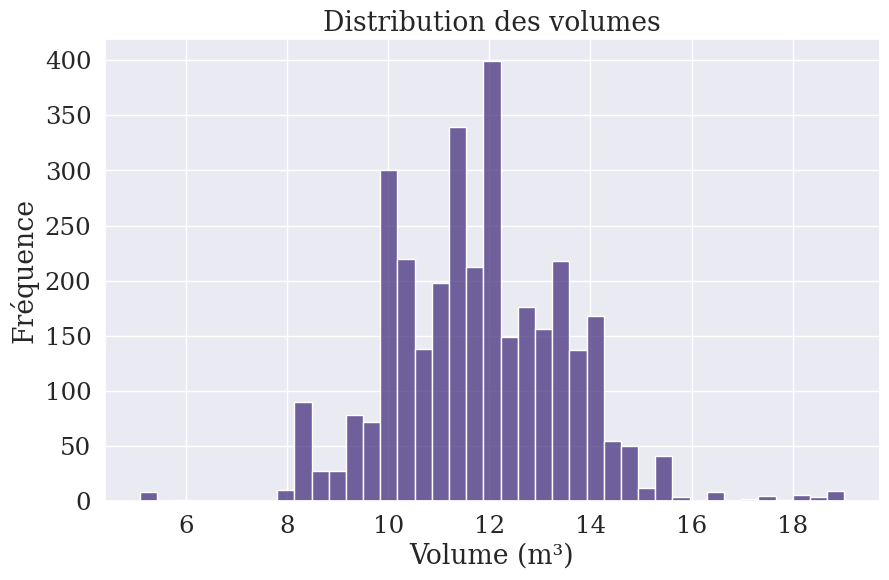

In [ ]:
volume_data = df_concat['Volume'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(volume_data)
plt.title('Distribution des volumes')
plt.xlabel('Volume (m³)')
plt.ylabel('Fréquence')
plt.show()

In [ ]:
voice_columns = ['Femme_Acteur', 'Femme_Voix-off', 'Homme_Acteur', 'Homme_Voix-off']
plot_data = []

for voice_type in voice_columns:
    # Filter: Keep rows where this specific voice type is present
    # fillna(0) handles cases where there is no script info (NaN)
    mask = df_concat[voice_type].fillna(0) > 0

    # Take the volume data for these rows
    subset = df_concat.loc[mask, 'Volume']

    # Create a temporary dataframe for this category
    temp_df = pd.DataFrame({
        'Voice_Type': voice_type,
        'Volume': subset
    })
    plot_data.append(temp_df)

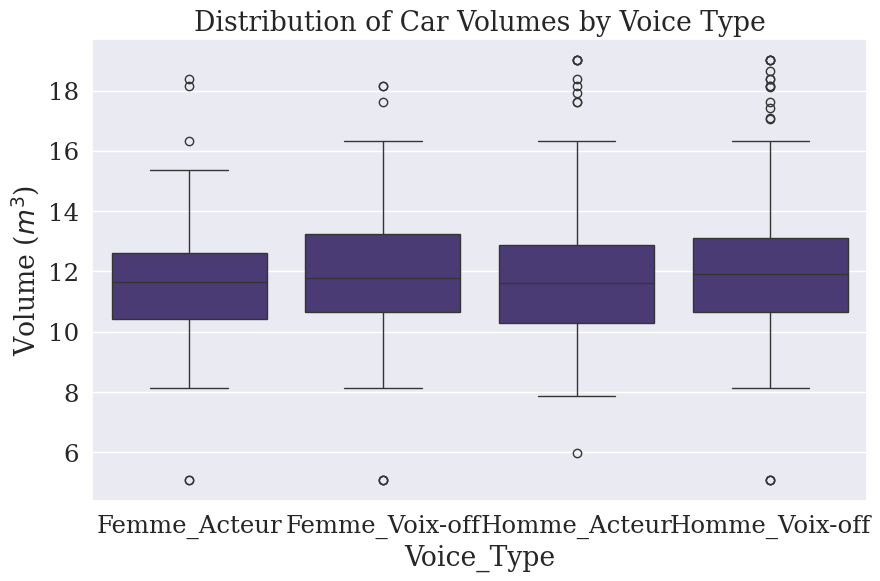

In [ ]:
# Concatenate all parts into one dataframe for plotting
df_plot = pd.concat(plot_data, ignore_index=True)

# 3. Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Voice_Type', y='Volume', data=df_plot)
plt.title('Distribution of Car Volumes by Voice Type')
plt.ylabel('Volume ($m^3$)')
plt.show()

## 4.5 Most frequent tokens matrix

In [26]:
nltk.download('stopwords')
stop_words = set(stopwords.words('french'))

df_filtered['Tokens'] = df_filtered['Tokens'].apply(ast.literal_eval)
df_exploded = df_filtered.explode('Tokens')

df_exploded = df_exploded[~df_exploded['Tokens'].isin(stop_words)]
df_exploded = df_exploded[~df_exploded['Tokens'].str.contains(r'\d', regex=True)]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
freq = (df_exploded.groupby(['Genre', 'Tokens']).size().reset_index(name='count'))

top_h = (freq[freq['Genre'] == 'Homme'].sort_values('count', ascending=False).head(15))

top_f = (freq[freq['Genre'] == 'Femme'].sort_values('count', ascending=False).head(15))

top_tokens = set(top_h['Tokens']).union(top_f['Tokens'])

In [29]:
matrix = (freq[freq['Tokens'].isin(top_tokens)].pivot(index='Tokens', columns='Genre', values='count').fillna(0).astype(int))
matrix['Total'] = matrix.sum(axis=1)
matrix = (matrix.sort_values('Total', ascending=False).drop(columns='Total'))

display(matrix)

Genre,Femme,Homme
Tokens,,
être,531,829
avoir,151,441
nouveau,208,308
tout,85,227
renault,139,141
électrique,139,125
euro,113,144
plus,61,176
aller,87,143


## 4.6 Vocabulaire et description du corpus

In [31]:
nb_mots_diff = df_exploded['Tokens'].nunique()
print(nb_mots_diff)

1910


In [33]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [34]:
def get_hyperonyms(token):
    hypernyms = set()

    synsets = wn.synsets(token, lang='fra')

    for syn in synsets:
        for h in syn.hypernyms():
            for lemma in h.lemmas(lang='fra'):
                hypernyms.add(lemma.name())

    return list(hypernyms)

In [35]:
tokens_uniques = df_exploded['Tokens'].unique()

token_to_hyper = {}

for token in tokens_uniques:
  hypers = get_hyperonyms(token)
  if hypers:
    token_to_hyper[token] = hypers

In [36]:
corpus_hyper = []

for token in df_exploded['Tokens']:
  if token in token_to_hyper and token_to_hyper[token]:
    corpus_hyper.append(token_to_hyper[token][0])

In [37]:
nb_hyperonyms_diff = len(set(corpus_hyper))
print(nb_hyperonyms_diff)

614


In [39]:
top_hypers = Counter(corpus_hyper).most_common(20)
df_hypers = pd.DataFrame(top_hypers, columns=['Hyperonyme', 'Fréquence'])
display(df_hypers)

,Hyperonyme,Fréquence
0,appréhender,1377
1,vouloir_dire,925
2,volume,627
3,automobile,391
4,chose,321
5,découvrir,311
6,domaine,306
7,qualité,269
8,traverser,263
9,réclamer,244


# 5. Data modelling

## 5.1 Gender and Nbr sentences by script

In [ ]:
# Statistiques descriptives
print("Moyenne de phrases par script:")
print(phrases_comparaison.mean())
print("\nÉcart-type:")
print(phrases_comparaison.std())
print()

# Test t apparié
t_stat, p_value = stats.ttest_rel(
    phrases_comparaison['Homme'],
    phrases_comparaison['Femme'],
    alternative='greater'  # Test unilatéral: Homme > Femme
)

print(f"Test t apparié:")
print(f"t = {t_stat:.3f}")
print(f"p-value = {p_value:.4f}")
print(f"Degrés de liberté = {len(phrases_comparaison)-1}")

Moyenne de phrases par script:


NameError: name 'phrases_comparaison' is not defined

## 5.2 Gender and Nbr tokens by sentence

In [ ]:
# Extract the normalized token proportions for each group
femme_tokens = df_filtered[df_filtered['Genre'] == 'Femme']['Nbr_tokens']
homme_tokens = df_filtered[df_filtered['Genre'] == 'Homme']['Nbr_tokens']

print("=== T-TEST RESULTS: Femme vs Homme (Nbr_tokens) ===")
print(f"Femme: n = {len(femme_tokens)}, mean = {femme_tokens.mean():.4f}, std = {femme_tokens.std():.4f}")
print(f"Homme: n = {len(homme_tokens)}, mean = {homme_tokens.mean():.4f}, std = {homme_tokens.std():.4f}")

# Perform independent t-test
t_stat, p_value, df_ttest = stests.ttest_ind(
    femme_tokens,
    homme_tokens,
    alternative='two-sided',  # Two-tailed test
    usevar='unequal'  # Welch's t-test (unequal variances)
)

print(f"\nT-test results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {df_ttest:.2f}")


# Additional statistics
print(f"\nEffect size (Cohen's d):")
# Manual calculation of Cohen's d
mean_diff = femme_tokens.mean() - homme_tokens.mean()
pooled_std = np.sqrt((femme_tokens.std()**2 + homme_tokens.std()**2) / 2)
cohens_d = mean_diff / pooled_std
print(f"Cohen's d: {cohens_d:.4f}")

# Interpretation of effect size
if abs(cohens_d) < 0.2:
    effect_size = "negligible"
elif abs(cohens_d) < 0.5:
    effect_size = "small"
elif abs(cohens_d) < 0.8:
    effect_size = "medium"
else:
    effect_size = "large"
print(f"Effect size interpretation: {effect_size}")

=== T-TEST RESULTS: Femme vs Homme (Nbr_tokens) ===
Femme: n = 1863, mean = 6.7112, std = 4.6606
Homme: n = 3742, mean = 6.4027, std = 4.5083

T-test results:
T-statistic: 2.3597
P-value: 0.0183
Degrees of freedom: 3610.89

Effect size (Cohen's d):
Cohen's d: 0.0673
Effect size interpretation: negligible


## 5.3 Gender and Type_voice

In [ ]:
# Table de contingence pour le chi-deux
contingency_table = df_filtered.groupby(['Genre', 'Type_voix'])['Nbr_tokens'].sum().unstack(fill_value=0)
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Résultats du chi-deux
print(f"Valeur du Chi-carré : {chi2:.4f}")
print(f"p-value : {p:.4e}")

# Proportions conditionnelles
genre_proportions = contingency_table.apply(lambda x: x / x.sum(), axis=1)
prop_f_voixoff = genre_proportions.loc['Femme', 'Voix-off']
prop_h_voixoff = genre_proportions.loc['Homme', 'Voix-off']
print()
print("Tokens pronconcés par des Femmes en Voix-off : "
          f"{prop_f_voixoff:.2%}")
print("Tokens pronconcés par des Hommes en Voix-off : "
          f"{prop_h_voixoff:.2%}")

Valeur du Chi-carré : 210.6736
p-value : 9.7929e-48

Tokens pronconcés par des Femmes en Voix-off : 56.74%
Tokens pronconcés par des Hommes en Voix-off : 48.73%


## 5.4 Gender and car volume

In [ ]:
display(df_concat.head(3))
df_concat.info()

,Script_Index,Produit,Script,Titre,Femme_Acteur,Femme_Voix-off,Homme_Acteur,Homme_Voix-off,Indéterminé_Acteur,Indéterminé_Voix-off,...,Diff_tokens_gender,MotsClés,Thème,Electric,Hybrid,Modèle,Longueur (mm),Largeur (mm),Hauteur (mm),Volume
0,0,CAPTURCALL FR,"L'homme (1) : "" Wou !\r\n (1) ... On va où Mon...",EN VOITURE,22,0,16,0,0,0,...,-6,CAMERA CACHEE,"INTERROGATION, HUMOUR AUTRE, NOCTURNE, TWITTER",0,0,Renault Captur,4228.0,1797.0,1566.0,11.90
1,1,NISSAN LEAF ELECTRIQUE,"Voix homme : "" 85 000 conducteurs vivent la se...",LA SENSATION 100% ELECTRIQUE,0,0,0,6,0,0,...,6,BALLON,"INNOVATION, UNIVERS URBAIN, ANGLAIS, EFFET, SI...",1,0,Nissan Leaf,4490.0,1789.0,1540.0,12.37
2,2,CITROEN LES OFFRES QUI TOMBENT A PIC C3,"La femme (1) : "" C'est votre voiture ?\r\n L'h...",LA MÉTÉORITE,4,0,1,0,0,0,...,-3,"CHANCE , POMPIER , CAMERA , INTERVIEW , METEOR...","ORIGINE, GARANTIE, ESPACE, JOURNALISTIQUE, DIS...",0,0,Citroën C3,3996.0,1748.0,1474.0,10.30


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4188 entries, 0 to 4187
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Script_Index          4188 non-null   int64  
 1   Produit               4188 non-null   object 
 2   Script                4006 non-null   object 
 3   Titre                 4188 non-null   object 
 4   Femme_Acteur          4188 non-null   int64  
 5   Femme_Voix-off        4188 non-null   int64  
 6   Homme_Acteur          4188 non-null   int64  
 7   Homme_Voix-off        4188 non-null   int64  
 8   Indéterminé_Acteur    4188 non-null   int64  
 9   Indéterminé_Voix-off  4188 non-null   int64  
 10  Total_Homme           4188 non-null   int64  
 11  Total_Femme           4188 non-null   int64  
 12  Diff_tokens_gender    4188 non-null   int64  
 13  MotsClés              3904 non-null   object 
 14  Thème                 4180 non-null   object 
 15  Electric             

In [ ]:
# Performing of a linar regression
model = smf.ols(formula = 'Diff_tokens_gender ~ Volume', data = df_concat)
result = model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:     Diff_tokens_gender   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                 0.0005716
Date:                Wed, 21 Jan 2026   Prob (F-statistic):              0.981
Time:                        10:01:41   Log-Likelihood:                -11966.
No. Observations:                3320   AIC:                         2.394e+04
Df Residuals:                    3318   BIC:                         2.395e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.7902      1.065      2.621      0.0